# Segmentação utilizando o modelo YOLO

## Segmentação


0: 384x640 15 persons, 2 backpacks, 4 handbags, 35.8ms
Speed: 0.7ms preprocess, 35.8ms inference, 15.3ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

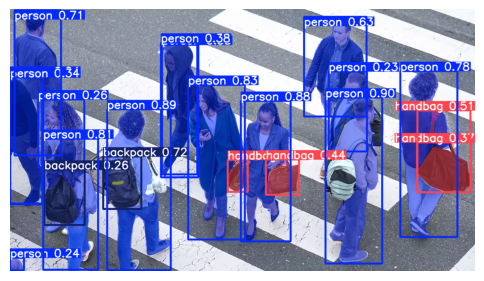

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

img = Image.open("../../dados/pedestrians.png")

result = model(
    img, 
    conf=0.2, 
    # Retorna máscaras com a mesma resolução da imagem de entrada
    retina_masks=True  
    )[0]

img_res = result.plot(
    conf=True,  
    boxes=True, 
    labels=True,  
    masks=True,  
)

img_res = img_res[:, :, ::-1]  # Converte BGR para RGB

plt.figure(figsize=(6, 8))
plt.imshow(img_res)
plt.axis("off")


In [19]:
masks = result.masks
# masks.shape[0] indica o número de máscaras detectadas
print(masks.shape)

torch.Size([21, 720, 1280])


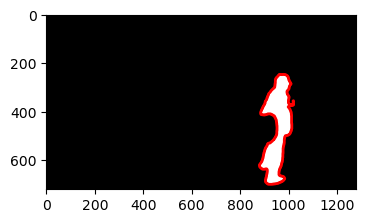

In [ ]:
# Máscara e contorno do primeiro objeto detectado
mask = masks.data[0]  
contour = masks.xy[0]

plt.imshow(mask, cmap="gray")
plt.plot(contour[:, 0], contour[:, 1], color="red", linewidth=2)

